In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# This is the function that helps plot feature importance
from xgboost import plot_importance

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
Dataset1 = pd.read_csv("/content/heart.csv")
Dataset1.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Data Cleaning

In [ ]:
Dataset1.size

14350

In [ ]:
Dataset1.shape

(1025, 14)

The dataset has 14 columns, 1025 rows and the size is 14350

In [ ]:
Dataset1.ndim

2

In [ ]:
# Get the basic information about the data
Dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


 Most of the data types are integer and float.

In [ ]:
# Generate a table of descriptive statistics.
Dataset1.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
Dataset1.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
Dataset1.duplicated().sum()

np.int64(723)

There are 723 duplicates observations in the data.

In [ ]:
Dataset2 = Dataset1.drop_duplicates()
Dataset2.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
#Verify
Dataset2.duplicated().sum()

np.int64(0)

,proportion
target,
1,0.543046
0,0.456954


Approximately 54.3% of the dataset represents 1 and 45.7% represents 0, so the outcome variable is balanced.

Exploratory Data Analysis

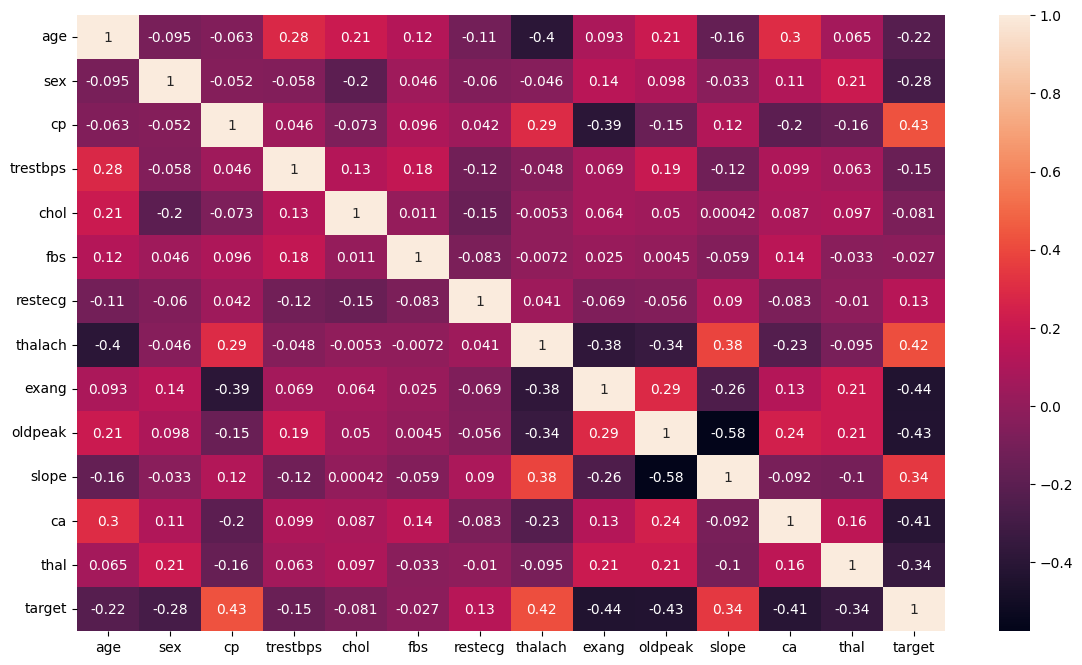

In [ ]:
plt.figure(figsize = (14,8))
sns.heatmap(Dataset2.corr(), annot= True)
plt.show()

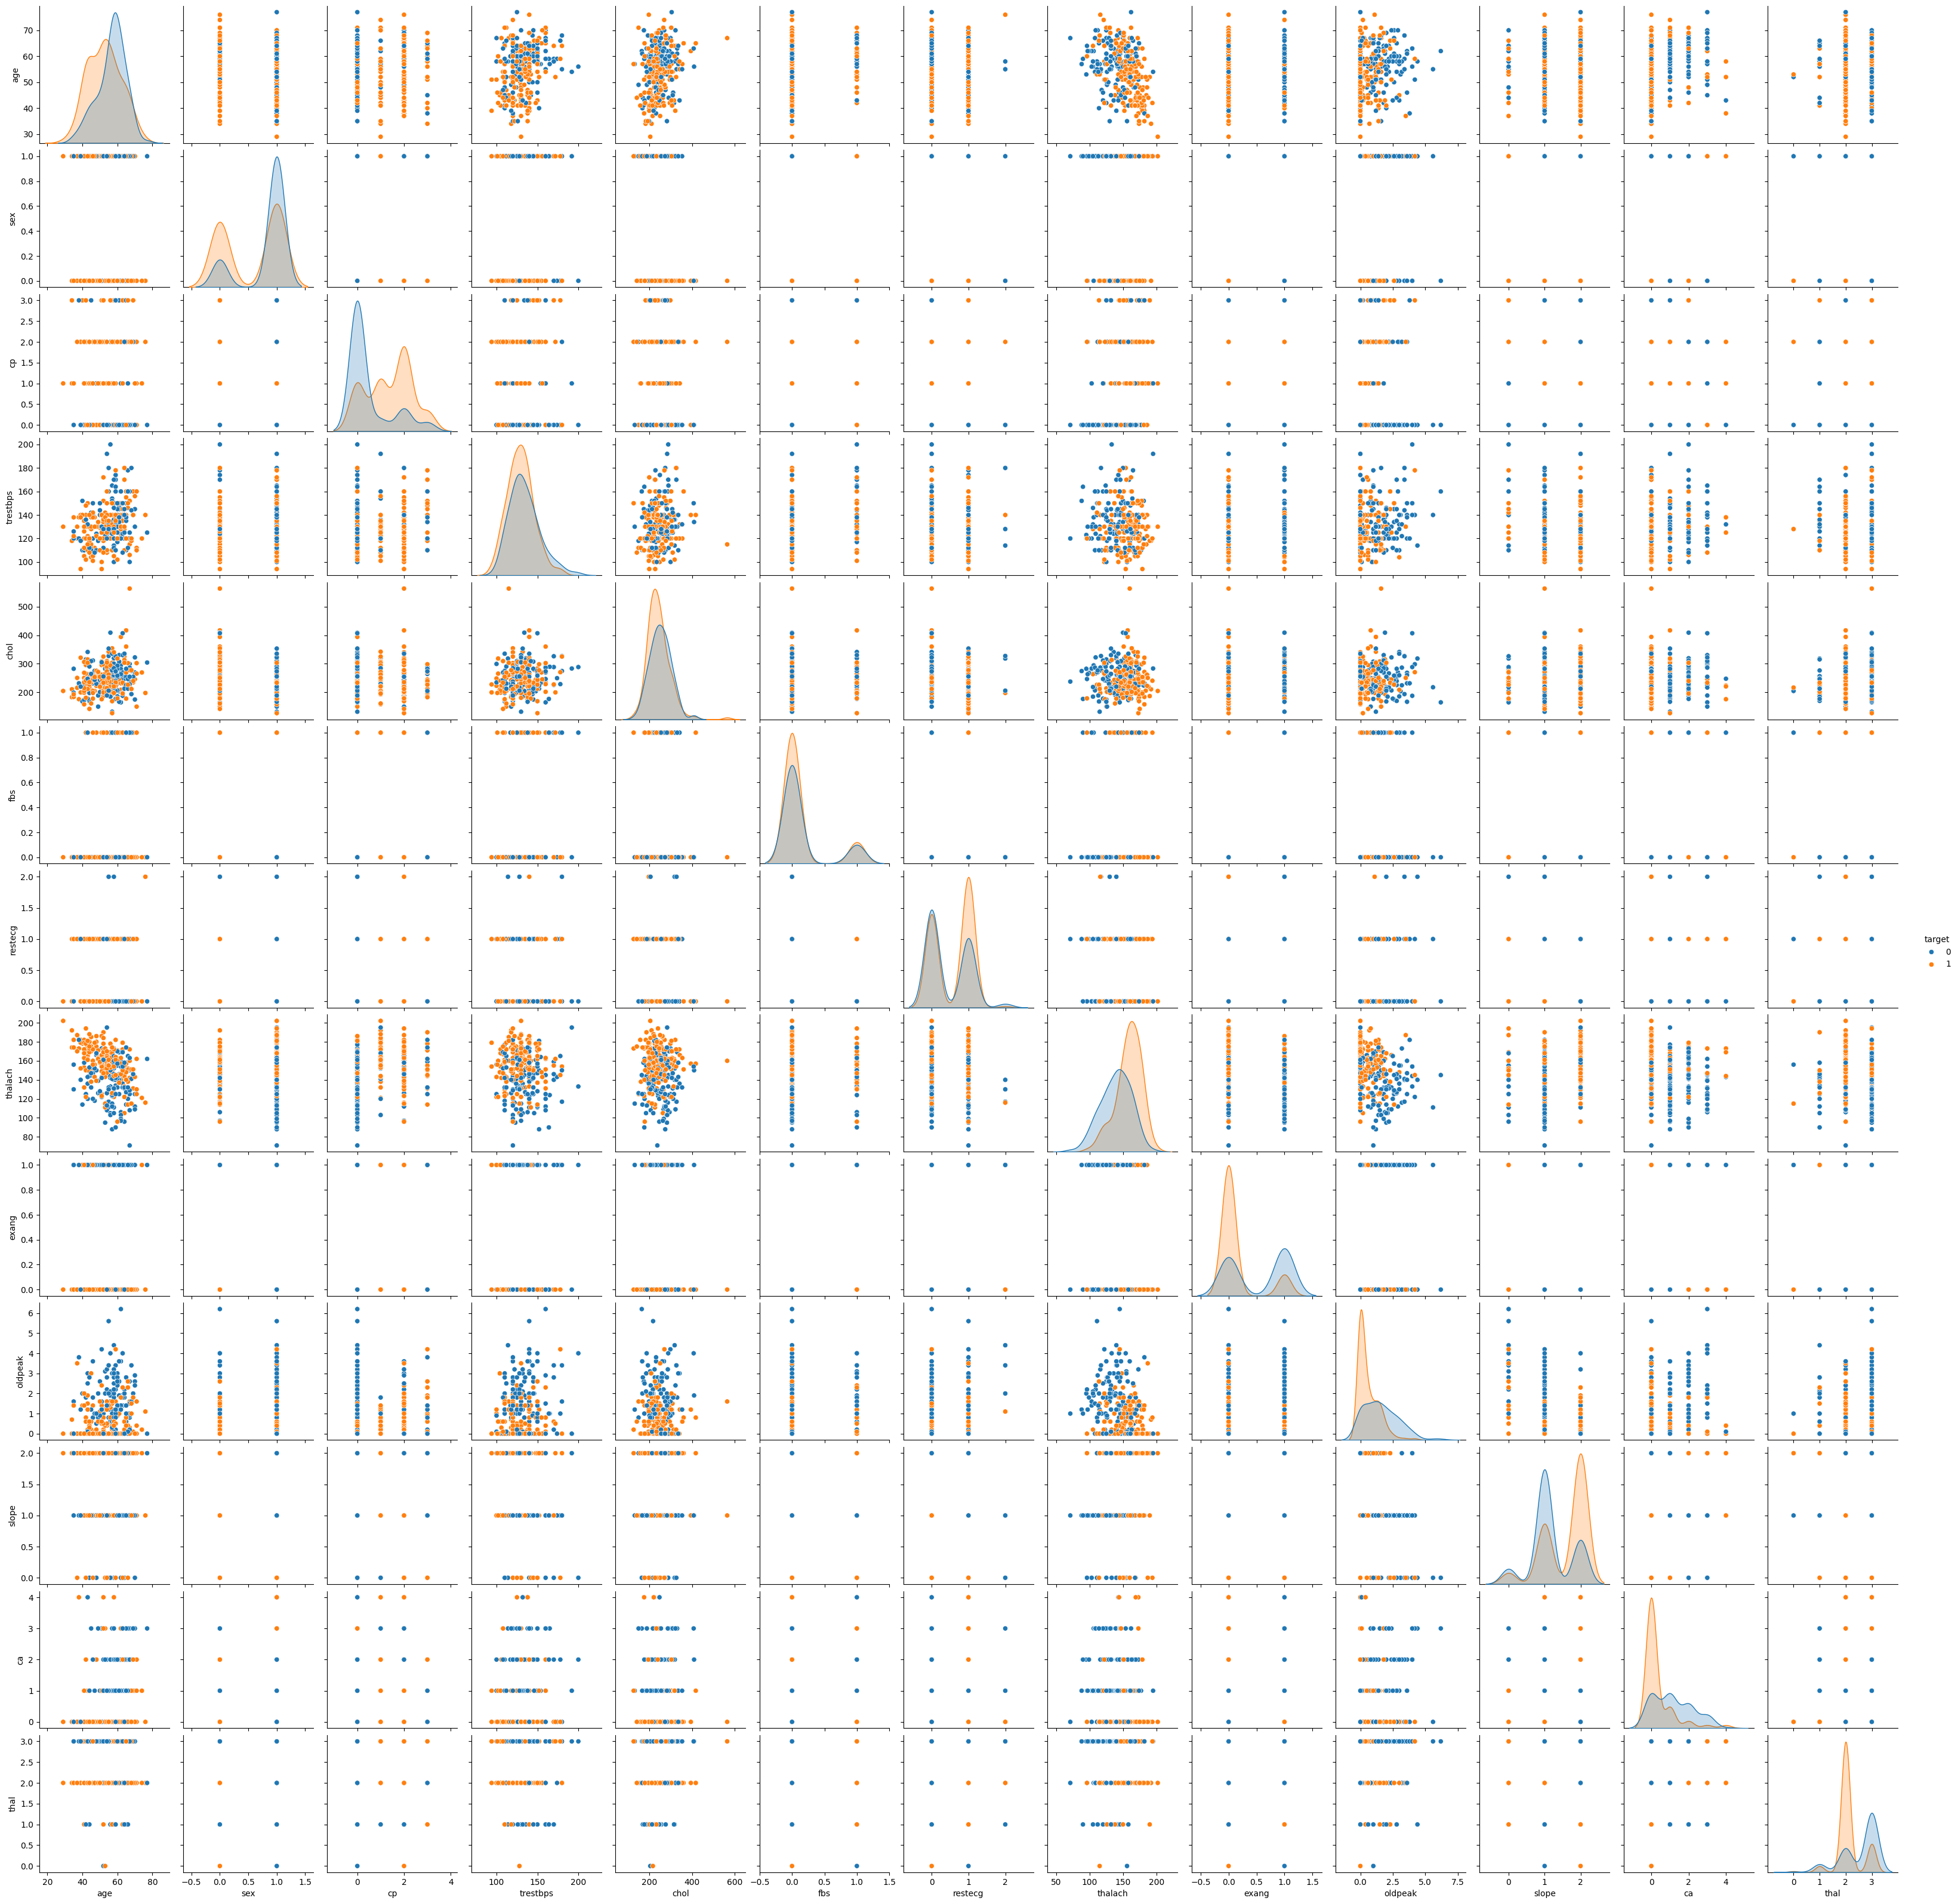

In [ ]:
sns.pairplot(Dataset2, hue= 'target')
plt.show()

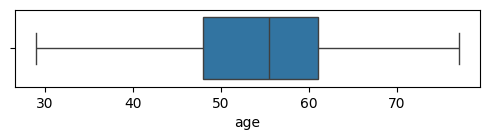

In [ ]:
# Create a boxplot to visualize distribution of "age"
plt.figure(figsize = (6, 1))
sns.boxplot(x = Dataset2['age'])
plt.show()

The variable age does not have outlier.

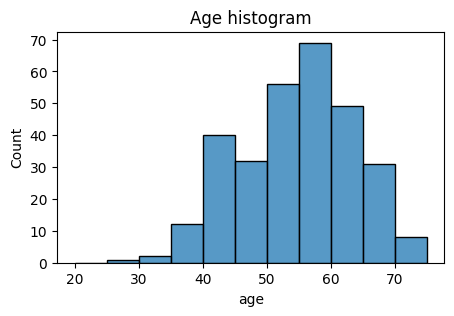

In [ ]:
#Create a histogram of the age column to further explore the distribution of this variable.
plt.figure(figsize=(5,3))
sns.histplot(Dataset2['age'], bins=range(20,80,5))
plt.title('Age histogram');

The distribution of age is align to left

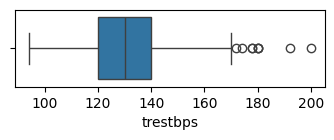

In [ ]:
# Create a boxplot to visualize distribution of "trestbps"
plt.figure(figsize = (4, 1))
sns.boxplot(x = Dataset2['trestbps'])
plt.show()

There are some outliers for this feature

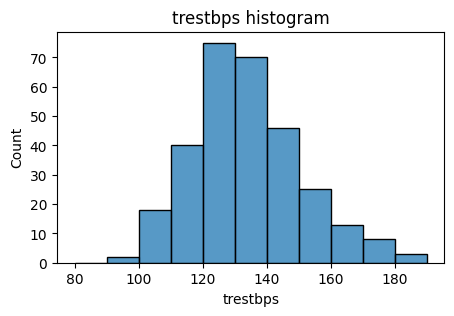

In [ ]:
#Create a histogram of the trestbps column to further explore the distribution of this variable.
plt.figure(figsize=(5,3))
sns.histplot(Dataset2['trestbps'], bins=range(80,200,10))
plt.title('trestbps histogram');

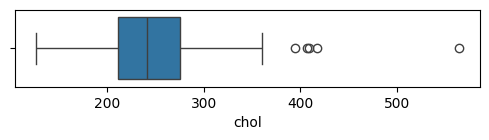

In [ ]:
# Create a boxplot to visualize distribution of "chol"
plt.figure(figsize = (6, 1))
sns.boxplot(x = Dataset2['chol'])
plt.show()

There exist some outliers for this variables

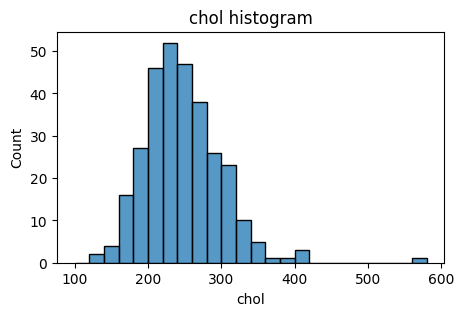

In [ ]:
#Create a histogram of the chol column to further explore the distribution of this variable.
plt.figure(figsize=(5,3))
sns.histplot(Dataset2['chol'], bins=range(100,600,20))
plt.title('chol histogram');

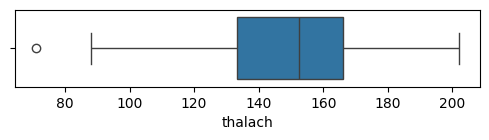

In [ ]:
# Create a boxplot to visualize distribution of "thalach"
plt.figure(figsize = (6, 1))
sns.boxplot(x = Dataset2['thalach'])
plt.show()

Presence of outliers for this feature

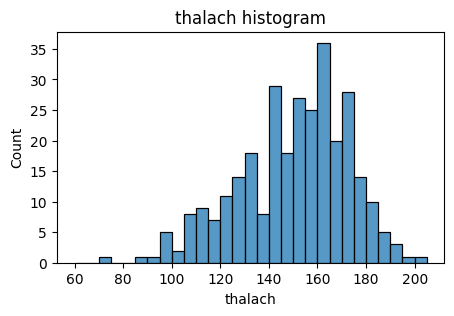

In [ ]:
#Create a histogram of the thalach column to further explore the distribution of this variable.
plt.figure(figsize=(5,3))
sns.histplot(Dataset2['thalach'], bins=range(60,210,5))
plt.title('thalach histogram');

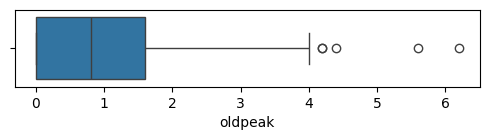

In [ ]:
# Create a boxplot to visualize distribution of "oldpeak"
plt.figure(figsize = (6, 1))
sns.boxplot(x = Dataset2['oldpeak'])
plt.show()

There are some outliers in this variable

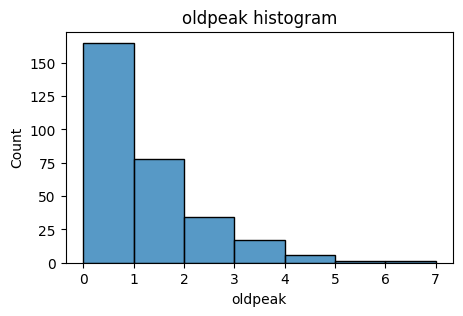

In [ ]:
#Create a histogram of the bmi column to further explore the distribution of this variable.
plt.figure(figsize=(5,3))
sns.histplot(Dataset2['oldpeak'], bins=range(0,8,1))
plt.title('oldpeak histogram');

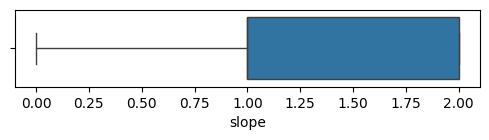

In [ ]:
# Create a boxplot to visualize distribution of "slope"
plt.figure(figsize = (6, 1))
sns.boxplot(x = Dataset2['slope'])
plt.show()

Text(0.5, 1.0, 'age Histogram')

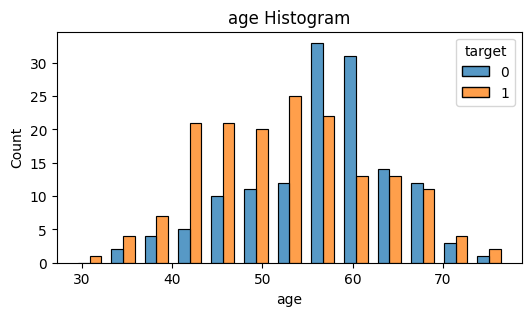

In [ ]:
plt.figure(figsize=(6,3))
sns.histplot(x = "age",
             hue= "target",
             multiple= "dodge",
             shrink= 0.7, data = Dataset2)
plt.title("age Histogram")

Text(0.5, 1.0, 'trestbps Histogram')

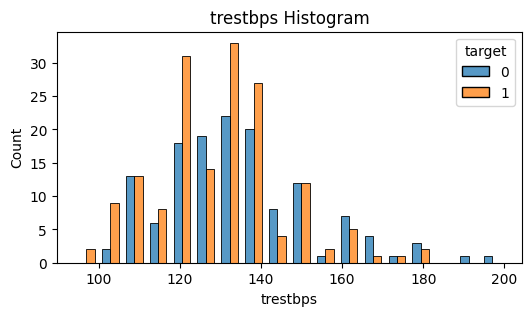

In [ ]:
plt.figure(figsize=(6,3))
sns.histplot(x = "trestbps",
             hue= "target",
             multiple= "dodge",
             shrink= 0.7, data = Dataset2)
plt.title("trestbps Histogram")

Text(0.5, 1.0, 'chol Histogram')

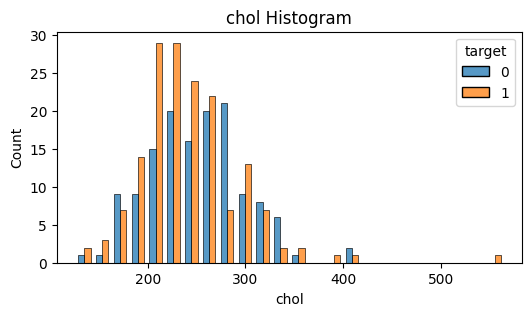

In [ ]:
plt.figure(figsize=(6,3))
sns.histplot(x = "chol",
             hue= "target",
             multiple= "dodge",
             shrink= 0.7, data = Dataset2)
plt.title("chol Histogram")

In [ ]:
#Determining outliers  # Count the number of values that exceed the outlier threshold
def det(Dataset2):
 cols = ['trestbps', 'chol','thalach','oldpeak']
 for col in cols:
  q1 = Dataset2[col].quantile(0.25)
  q3 = Dataset2[col].quantile(0.75)
  iqr = q3 - q1
  median = Dataset2[col].median()
  outliers_threshold = median + 1.5*iqr
  outlier_count = (Dataset2[col] > outliers_threshold).sum()
  print(f'Number of outliers, {col}:', outlier_count)
  lower = dataset.min() - 3*dataset[col].median()
  upper = dataset.max() + 3*dataset.median()
  dataset = np.where(dataset > upper, upper,
            np.where(dataset < lower,
            lower, dataset))

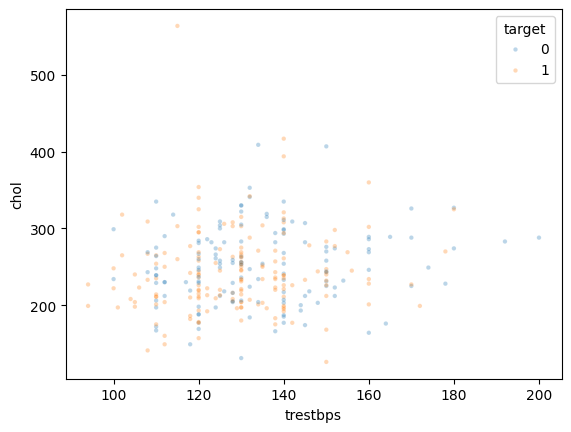

In [ ]:
# Create a scatterplot of `trestbps` versus `chol` according to 'target'
sns.scatterplot(x=Dataset2["trestbps"], y=Dataset2["chol"],
                hue=Dataset2["target"], s=10, alpha=.3)
plt.show()

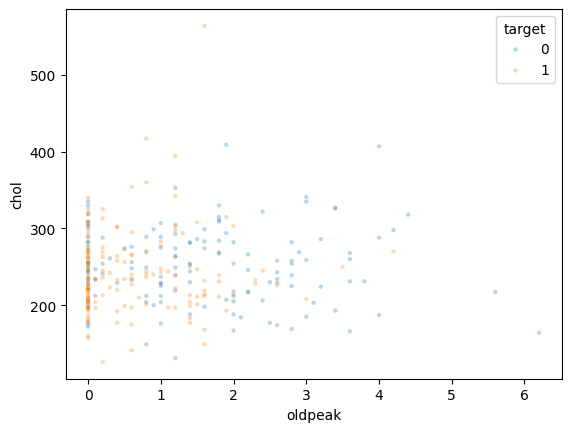

In [ ]:
# Create a scatterplot of `trestbps` versus `chol` according to 'target'
sns.scatterplot(x=Dataset2["oldpeak"], y=Dataset2["chol"],
                hue=Dataset2["target"], s=10, alpha=.3)
plt.show()

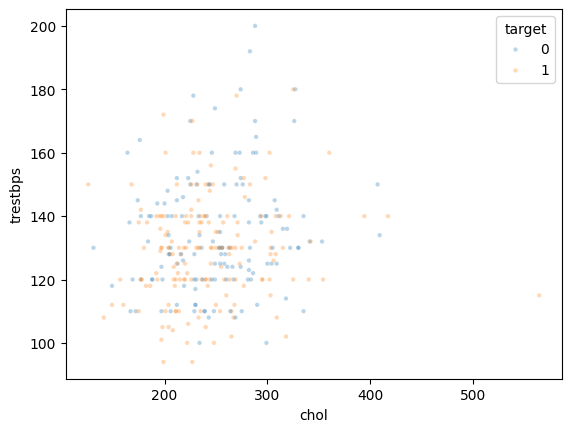

In [ ]:
# Create a scatterplot of `trestbps` versus `chol` according to 'target'
sns.scatterplot(x=Dataset2["chol"], y=Dataset2["trestbps"],
                hue=Dataset2["target"], s=10, alpha=.3)
plt.show()

Modeling

In [ ]:
X = Dataset2.drop(columns = ['target'])
y = Dataset2[['target']]
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()  # crating the object

X_new1 = sc.fit_transform(X)
X_new1 = pd.DataFrame(X_new1)
X_new1.head(10)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.267966,0.682656,-0.935208,-0.376556,-0.667728,-0.418446,0.901657,0.806035,-0.698344,-0.037124,0.979514,1.274980,1.119967
1,-0.157260,0.682656,-0.935208,0.478910,-0.841918,2.389793,-1.002541,0.237495,1.431958,1.773958,-2.271182,-0.714911,1.119967
2,1.724733,0.682656,-0.935208,0.764066,-1.403197,-0.418446,0.901657,-1.074521,1.431958,1.342748,-2.271182,-0.714911,1.119967
3,0.728383,0.682656,-0.935208,0.935159,-0.841918,-0.418446,0.901657,0.499898,-0.698344,-0.899544,0.979514,0.280034,1.119967
4,0.839089,-1.464866,-0.935208,0.364848,0.919336,2.389793,0.901657,-1.905464,-0.698344,0.739054,-0.645834,2.269926,-0.513994
5,0.396267,-1.464866,-0.935208,-1.802334,0.029032,-0.418446,-1.002541,-1.205722,-0.698344,-0.037124,-0.645834,-0.714911,-0.513994
6,0.396267,0.682656,-0.935208,-1.003898,1.383842,-0.418446,2.805854,-0.418513,-0.698344,2.895104,-2.271182,2.269926,-2.147955
7,0.064151,0.682656,-0.935208,1.619532,0.822564,-0.418446,-1.002541,-0.199843,1.431958,-0.209608,-0.645834,0.280034,1.119967
8,-0.932199,0.682656,-0.935208,-0.661712,0.048386,-0.418446,-1.002541,-0.243577,-0.698344,-0.209608,0.979514,-0.714911,1.119967
9,-0.046555,0.682656,-0.935208,-0.547650,0.764500,-0.418446,-1.002541,-1.468126,1.431958,1.860200,-0.645834,1.274980,-0.513994


In [ ]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_new1, y, stratify=y, test_size=0.2, random_state=42)

Logistic Regression

In [29]:
# Creating the Model
Model2 = LogisticRegression()
# fit function - Training Time of Model
Model2.fit(X_train, y_train)

LogisticRegression()

In [31]:
# prediction --> y_pred

y_predLR = Model2.predict(X_test)

y_predLR

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1])

Performance Evaluation

In [32]:
print(accuracy_score(y_test, y_predLR))

0.8032786885245902


Loss Function in Binary Classification

In [ ]:
from sklearn.metrics import log_loss
y_pred_proba = Model2.predict_proba(X_test)
y_pred_proba

array([[0.81422371, 0.18577629],
       [0.29168376, 0.70831624],
       [0.99290274, 0.00709726],
       [0.43547459, 0.56452541],
       [0.08701626, 0.91298374],
       [0.99379666, 0.00620334],
       [0.17559175, 0.82440825],
       [0.9816059 , 0.0183941 ],
       [0.02223638, 0.97776362],
       [0.38608894, 0.61391106],
       [0.06509654, 0.93490346],
       [0.64743654, 0.35256346],
       [0.27676584, 0.72323416],
       [0.06478047, 0.93521953],
       [0.80004899, 0.19995101],
       [0.01787276, 0.98212724],
       [0.35119405, 0.64880595],
       [0.96623591, 0.03376409],
       [0.00502128, 0.99497872],
       [0.30512759, 0.69487241],
       [0.515477  , 0.484523  ],
       [0.98513046, 0.01486954],
       [0.33730398, 0.66269602],
       [0.94259943, 0.05740057],
       [0.32322375, 0.67677625],
       [0.99277794, 0.00722206],
       [0.99828454, 0.00171546],
       [0.63306759, 0.36693241],
       [0.9506809 , 0.0493191 ],
       [0.06276214, 0.93723786],
       [0.

In [33]:
print(log_loss(y_test, y_pred_proba))

0.47308970753406554


In [35]:
#calculating AUC
AUC_LR = roc_auc_score(y_test, y_predLR)
print("AUC_LR Score: {:.2f}%".format(AUC_LR*100))

AUC_LR Score: 79.92%


Random Forest

In [ ]:
# 1. Instantiate the random forest classifier
rf = RandomForestClassifier(random_state=42)

# 2. Create a dictionary of hyperparameters to tune
# Note that this example only contains 1 value for each parameter for simplicity,
# but you should assign a dictionary with ranges of values
# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5, 7, None],
             'max_features': [0.3, 0.6],
            #  'max_features': 'auto'
             'max_samples': [0.7],
             'min_samples_leaf': [1,2],
             'min_samples_split': [2,3],
             'n_estimators': [75,100,200],
             }

# 3. Define a set of scoring metrics to capture
#scoring = {'accuracy', 'precision', 'recall', 'f1'}

# 4. Instantiate the GridSearchCV object
rf1 = GridSearchCV(rf, cv_params, cv=4, refit='f1')

In [26]:
%%time
rf1.fit(X_train, y_train)

CPU times: user 1min 6s, sys: 337 ms, total: 1min 6s
Wall time: 1min 7s


GridSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [75, 100, 200]},
             refit='f1')

In [37]:
y_predRF = rf1.predict(X_test)
y_predRF

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0])

In [ ]:
print(accuracy_score(y_test, y_predRF))

0.7868852459016393


In [38]:
#calculating AUC
#y_pred_probaLR = LR.predict_proba(X_test)
AUC_RF = roc_auc_score(y_test, y_predRF)
print("AUC_RF Score: {:.2f}%".format(AUC_RF*100))

AUC_RF Score: 78.68%


SVM Classification

In [39]:
from sklearn.svm import SVC
svm_classifier = SVC(kernel='rbf', random_state= 42)
svm_classifier.fit(X_train, y_train)

SVC(random_state=42)

In [40]:
y_predSVM = svm_classifier.predict(X_test)
y_predSVM

array([0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1])

In [41]:
#y_pred_probaSVM = svm_classifier.predict_proba(X_test)[:, 1]
AUC_SVM = roc_auc_score(y_test, y_predSVM)
print("AUC_SVM Score: {:.2f}%".format(AUC_SVM*100))

AUC_SVM Score: 76.62%


In [43]:
from xgboost import XGBClassifier
model = XGBClassifier(objective='binary:logistic')
model.fit(X_train, y_train)
y_predXGB = model.predict(X_test)


In [44]:
AUC_XGB = roc_auc_score(y_test, y_predXGB)
print("AUC_XGB Score: {:.2f}%".format(AUC_XGB*100))

AUC_XGB Score: 71.81%


In [45]:
from sklearn.neighbors import KNeighborsClassifier
modelKNN = KNeighborsClassifier(n_neighbors= 5)
modelKNN.fit(X_train, y_train)

KNeighborsClassifier()

In [47]:
y_predKNN = modelKNN.predict(X_test)
AUC_KNN = roc_auc_score(y_test, y_predKNN)
print("AUC_KNN Score: {:.2f}%".format(AUC_KNN*100))

AUC_KNN Score: 78.14%


In [50]:
from sklearn.ensemble import AdaBoostClassifier
modelAB = AdaBoostClassifier(n_estimators = 100)   # default is 50
modelAB.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=100)

In [52]:
#calculating AUC
y_predAB = modelAB.predict(X_test)
AUC_AB = roc_auc_score(y_test, y_predAB)
print("AUC_AB Score: {:.2f}%".format(AUC_AB*100))

AUC_AB Score: 74.13%


In [54]:
from sklearn.tree import DecisionTreeClassifier
Model1 = DecisionTreeClassifier()
Model1.fit(X_train, y_train)

DecisionTreeClassifier()

In [55]:
y_predDT = Model1.predict(X_test)
AUC_DT = roc_auc_score(y_test, y_predDT)
print("AUC_DT Score: {:.2f}%".format(AUC_DT*100))

AUC_DT Score: 80.47%


In [56]:
Results = pd.DataFrame({"Models": ["Decision Tree","Logistic Regression", "Random Forest", "XGBoost","KNN", "Adaboost"],
                        "AUC Score" : [ AUC_DT, AUC_LR,AUC_RF, AUC_XGB, AUC_KNN, AUC_AB]})
Results.sort_values(by = "AUC Score", ascending = False)

,Models,AUC Score
0,Decision Tree,0.804654
1,Logistic Regression,0.799242
2,Random Forest,0.786797
4,KNN,0.781385
5,Adaboost,0.741342
3,XGBoost,0.718074


<Figure size 1600x800 with 0 Axes>

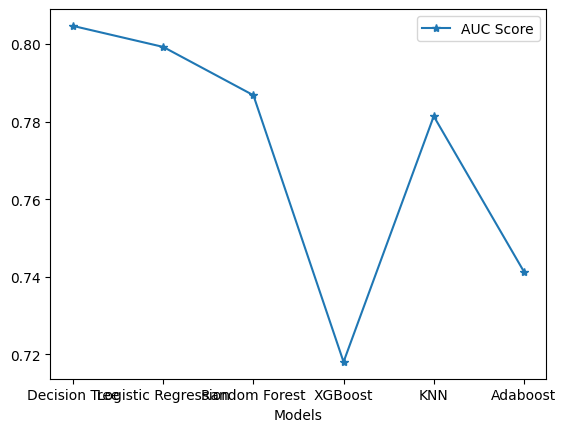

In [57]:
plt.figure(figsize=(16,8))
Results.plot(x = "Models", y = "AUC Score", kind = "line", marker = "*")
plt.show()